In [36]:
import os
import dotenv
import pandas as pd
import pyodbc
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

dotenv.load_dotenv()


# Connection string using the specific InterSystems ODBC driver
# Note: Ensure the driver name exactly matches what is installed on your client
# Updated with the correct driver name from your system
connection_string = (
    f"DRIVER={{InterSystems IRIS ODBC35}};"
    f"SERVER={os.getenv('IRIS_SERVER')};"
    f"PORT={os.getenv('IRIS_PORT')};"
    f"DATABASE={os.getenv('IRIS_NAMESPACE')};"
    f"UID={os.getenv('IRIS_USERNAME')};"
    f"PWD={os.getenv('IRIS_PASSWORD')}"
)

In [37]:
past_date_str = "2024-01-01 00:00:00"
past_datetime = datetime.datetime.strptime(past_date_str, "%Y-%m-%d %H:%M:%S")
current_datetime = datetime.datetime.now()

with pyodbc.connect(connection_string) as cnxn:
    PointSamples_df = pd.read_sql(f"SELECT * FROM MLpipeline.PointSamples WHERE datetime >= '{past_datetime}' AND datetime <= '{current_datetime}'", cnxn)
    points_w_groundtruth = PointSamples_df[PointSamples_df.y.notna()].ID
    Predictions_df = pd.read_sql(f"SELECT * FROM MLpipeline.Predictions WHERE pointsidforeignkey IN {tuple(points_w_groundtruth)}", cnxn)

C:\Users\jjaramil\AppData\Local\Temp\ipykernel_35040\1198911111.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  PointSamples_df = pd.read_sql(f"SELECT * FROM MLpipeline.PointSamples WHERE datetime >= '{past_datetime}' AND datetime <= '{current_datetime}'", cnxn)
C:\Users\jjaramil\AppData\Local\Temp\ipykernel_35040\1198911111.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Predictions_df = pd.read_sql(f"SELECT * FROM MLpipeline.Predictions WHERE pointsidforeignkey IN {tuple(points_w_groundtruth)}", cnxn)


In [38]:
points_w_groundtruth

0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
9     10
10    11
Name: ID, dtype: int64

In [39]:
eachmodelspred = Predictions_df.pivot_table(index="PointsIDForeignKey", columns="Modelrunid", values="YPred", aggfunc="mean")
merged_df = pd.merge(PointSamples_df, eachmodelspred, left_on="ID", right_on="PointsIDForeignKey", how="left")
modelnames = [col for col in merged_df.columns if col not in PointSamples_df.columns]

# Grained Comparison Plot

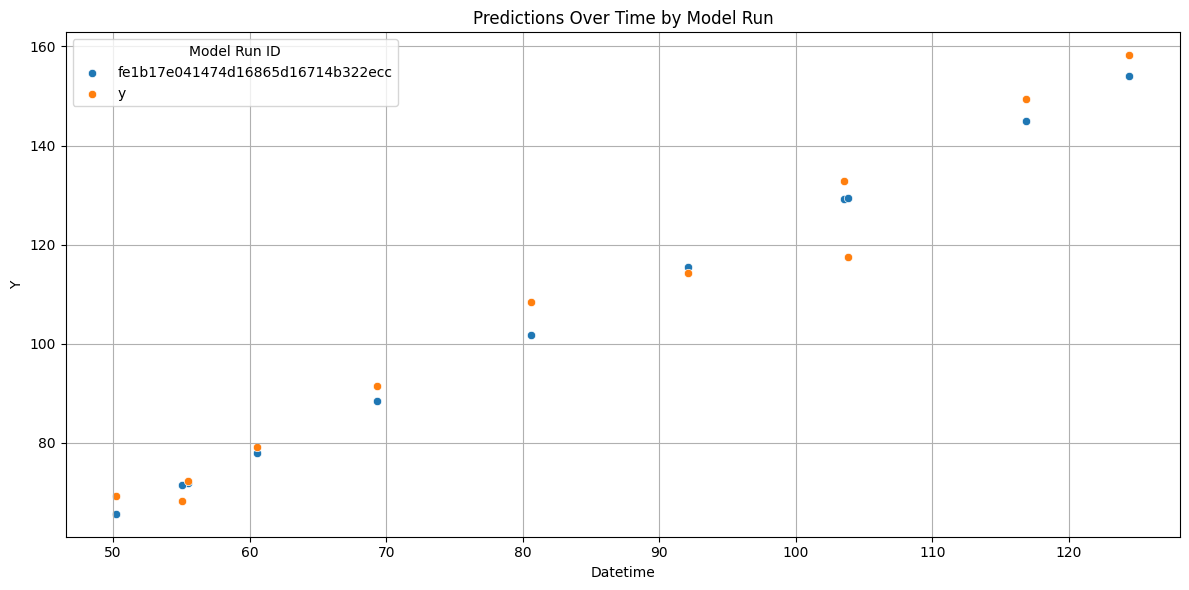

In [40]:
plt.figure(figsize=(12, 6))
for colname in modelnames + ["y"]:
    sns.scatterplot(data=merged_df, x="x", y=colname, label=colname)
plt.title("Predictions Over Time by Model Run")
plt.xlabel("Datetime")
plt.ylabel("Y")
plt.legend(title="Model Run ID")
plt.xticks()
plt.grid()
plt.tight_layout()

In [41]:
models_last_datetime = Predictions_df.groupby("Modelrunid").agg({"datetime":max})
latest_model = models_last_datetime["datetime"].idxmax()
latest_active_predictions = Predictions_df[Predictions_df["Modelrunid"] == latest_model].groupby("PointsIDForeignKey").agg({"YPred": "mean", "InferenceTime": "mean"}).reset_index()
latest_active_predictions = pd.merge(latest_active_predictions, PointSamples_df[["ID", "y"]], left_on="PointsIDForeignKey", right_on="ID", how="left")


C:\Users\jjaramil\AppData\Local\Temp\ipykernel_35040\1703254604.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  models_last_datetime = Predictions_df.groupby("Modelrunid").agg({"datetime":max})


In [42]:
latest_active_predictions

,PointsIDForeignKey,YPred,InferenceTime,ID,y
0,1,153.981640,0.002953,1,158.219061
1,2,144.971253,0.002953,2,149.320945
2,3,129.145179,0.002953,3,132.860754
3,4,115.483743,0.002953,4,114.202184
4,5,101.857779,0.002953,5,108.475385
5,6,88.407990,0.002953,6,91.432696
6,7,77.940844,0.002953,7,79.221061
7,8,71.977990,0.002953,8,72.364501
8,9,71.458975,0.002953,9,68.244973
9,10,65.705598,0.002953,10,69.234440


In [43]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(latest_active_predictions["y"], latest_active_predictions["YPred"])
r2 = r2_score(latest_active_predictions["y"], latest_active_predictions["YPred"])
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")


Mean Absolute Error: 3.9536521659258894
R-squared: 0.9739252245246689
